## RSVHub Analysis: Current Season Performance

This notebook evaluates performance of models currently submitting to the CDC's RSV Forecast Hub for target weekly incident RSV hospital admissions. For this analysis, we examine only the current season from 3 January to 1 April 2026. The inputs are quantile forecasts, and we examine 52 jurisdictions (50 states + Washington, DC + Puerto Rico). National-level (US) forecasts are excluded. Forecasts are submitted for horizons $[-1, 3]$, but this analysis excludes horizon $-1$.

The two main evaluation metrics are Weighted Interval Score (WIS) and log WIS (the same WIS scoring function applied to log transformed data), calculated in the same way as currently done for the CDC's own evaluations.

Main model comparisons consider only those models submitting for at least 80% of eligible forecasting tasks, where the task space is defined over the required combination of location, reference date and prediction horizon, i.e., `one forecast task = one model x one reference date x one horizon x one location`. For each task, the submitted quantile forecast is compared against the current observed hospital admissions for the corresponding `target_end_date`.

#### imports & setup

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.colors import LinearSegmentedColormap

from hub_config import RSV_HUB as HUB
from src.scoring import pairwise_relative_wis
import src.plotting as P
import src.colouring as C

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,          # base size
    "axes.titlesize": 16,     # subplot title
    "axes.labelsize": 15,     # x/y axis labels
    "xtick.labelsize": 12,    # x tick labels
    "ytick.labelsize": 12,    # y tick labels
    "legend.fontsize": 12,    # legend text
    "legend.title_fontsize": 12,
    "figure.titlesize": 18,   # suptitle
})

FOR_DISEASE = "rsv"
PLTS_TO = f'figures/hubs/{FOR_DISEASE}'
os.makedirs(PLTS_TO, exist_ok=True)

In [20]:
# Location scope
# Toggle to include / exclude jurisdiction from ALL analyses
EXCLUDE_NATIONAL    = True   # US national-level aggregate
EXCLUDE_PUERTO_RICO = False  # Puerto Rico (FIPS 72)

EXCLUDE_LOCS = (
    (["US"] if EXCLUDE_NATIONAL    else []) +
    (["72"] if EXCLUDE_PUERTO_RICO else [])
)
print(f"Excluding locations: {EXCLUDE_LOCS or 'none'}")

Excluding locations: ['US']


In [21]:
scores_all = pd.read_parquet(HUB.scores_path)
scores = scores_all[
    (scores_all["horizon"] != -1) &
    (~scores_all["location"].isin(EXCLUDE_LOCS))
].copy()

# Task space
ALL_DATES    = sorted(scores["reference_date"].unique())
ALL_HORIZONS = sorted(scores["horizon"].unique())    # [0, 1, 2, 3]
ALL_LOCS     = sorted(scores["location"].unique())

N_DATES, N_HORIZONS, N_LOCS = len(ALL_DATES), len(ALL_HORIZONS), len(ALL_LOCS)

_scoreable = scores.groupby(["reference_date", "horizon", "location"]).size()
MAX_TASKS   = len(_scoreable)
SCOREABLE_DH = scores.groupby(["reference_date", "horizon"]).ngroups

ELIGIBILITY_THRESHOLD = 0.80
ENSEMBLE   = HUB.ensemble_id
BASELINE   = HUB.baseline_id
GOOGLE     = HUB.google_id
HUB_MODELS = set(HUB.hub_model_ids)   # ensemble + baseline + extra ensembles


In [22]:
# Colour scheme
# Google = pink, hub models (ensemble, baseline, extra ensembles) = black, all others = grey
GREEN = C.GREEN
GOOGLE_PINK = C.GOOGLE_PINK
ALL_MODELS  = sorted(scores["model_id"].unique())
HUB_BLACK = C.HUB_BLACK
OTHER_GREY = C.OTHER_GREY
MODEL_COLOUR = {
    m: (
        GOOGLE_PINK if m == GOOGLE
        else HUB_BLACK if m in HUB_MODELS
        else OTHER_GREY
    )
    for m in scores["model_id"].unique()
}
MODEL_HATCH = {
    m: (
        "//" if m in HUB_MODELS
        else ""
    )
    for m in scores["model_id"].unique()
}

In [23]:
# Location submission check (here for Puerto Rico)
# Uses scores_all (before location filtering) -- how many models submit for this location?
CHECK_LOCATION = "72"  # Puerto Rico FIPS code
_loc  = scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == CHECK_LOCATION)]
_all = scores_all[ scores_all["horizon"] != -1]

if _loc.empty:
    print(f"{CHECK_LOCATION} has no scored tasks in this hub/season.")
else:
    _loc_count  = _loc.groupby("model_id").size().rename("Location tasks")
    _tot_count = _all.groupby("model_id").size().rename("Total tasks")
    _df = pd.concat([_loc_count, _tot_count], axis=1).fillna(0).astype(int)
    _df["% of own tasks"] = _df["Location tasks"] / _df["Total tasks"]
    _df = _df.sort_values("Location tasks", ascending=False)

    print(f"Location ({CHECK_LOCATION}) scored tasks : {len(_loc):,}  over {_loc['reference_date'].nunique()} reference dates")
    print(f"Models with location ({CHECK_LOCATION}) present : {(_df['Location tasks'] > 0).sum()} / {len(_df)}")
    display(
        _df.style
        .format({f"% of own tasks": "{:.1%}"})
        .background_gradient(subset=["Location tasks"], cmap="YlOrRd")
    )

Location (72) scored tasks : 168  over 12 reference dates
Models with location (72) present : 4 / 7


,Location tasks,Total tasks,% of own tasks
model_id,,,
CEPH-Rtrend_rsv,42,2226,1.9%
Google_SAI-RSVEns,42,2184,1.9%
RSVHub-baseline,42,2226,1.9%
RSVHub-ensemble,42,2226,1.9%
CFA_Pyrenew-Pyrenew_HE_RSV,0,1161,0.0%
CFA_Pyrenew-Pyrenew_H_RSV,0,1186,0.0%
UM-DeepOutbreak,0,494,0.0%


## Eligibility

In [24]:
model_n_tasks = scores.groupby("model_id").size().rename("n_tasks")
eligible_models = sorted(
    model_n_tasks[model_n_tasks / MAX_TASKS >= ELIGIBILITY_THRESHOLD].index
)

print(f"Task space: {N_DATES} dates × {N_HORIZONS} horizons × {N_LOCS} locs = {MAX_TASKS:,} max tasks/model")
print(f"Eligibility threshold: ≥{ELIGIBILITY_THRESHOLD:.0%}  (≥{int(ELIGIBILITY_THRESHOLD * MAX_TASKS):,} tasks)")
print(f"Eligible models: {len(eligible_models)}")

_pr_tasks = (
    scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == "72")]
    .groupby("model_id").size()
    .rename("pr_tasks")
)

_elig_tbl = pd.DataFrame({
    "Tasks":   model_n_tasks[eligible_models],
    "Tasks %": model_n_tasks[eligible_models] / MAX_TASKS,
}).join(_pr_tasks).fillna(0)
_elig_tbl["pr_tasks"] = _elig_tbl["pr_tasks"].astype(int)

display(
    _elig_tbl
    .rename(columns={"pr_tasks": "PR tasks"})
    .style
    .format({"Tasks": "{:,}", "Tasks %": "{:.1%}", "PR tasks": "{:,}"})
    .background_gradient(subset=["PR tasks"], cmap="YlOrRd")
)

Task space: 12 dates × 4 horizons × 52 locs = 2,184 max tasks/model
Eligibility threshold: ≥80%  (≥1,747 tasks)
Eligible models: 4


,Tasks,Tasks %,PR tasks
model_id,,,
CEPH-Rtrend_rsv,"2,184",100.0%,42
Google_SAI-RSVEns,"2,184",100.0%,42
RSVHub-baseline,"2,184",100.0%,42
RSVHub-ensemble,"2,184",100.0%,42


## Coverage

In [25]:
cov = (
    scores.groupby("model_id", as_index=False)
    .agg(
        n_ref_dates=("reference_date", "nunique"),
        n_horizons=("horizon", "nunique"),
        n_locations=("location", "nunique"),
        n_tasks=("wis", "size"),
    )
)

# Number of unique (reference_date × horizon) combinations submitted per model
n_dh = (
    scores.groupby(["model_id", "reference_date", "horizon"])
    .size()
    .groupby("model_id")
    .size()
    .rename("n_dh_combos")
    .reset_index()
)
cov = cov.merge(n_dh, on="model_id")

cov["pct_ref_dates"]   = cov["n_ref_dates"] / N_DATES
cov["pct_dh_combos"]   = cov["n_dh_combos"] / SCOREABLE_DH   # denominator = scoreable pairs only
cov["pct_tasks"]       = cov["n_tasks"]      / MAX_TASKS
cov["eligible"]        = cov["model_id"].isin(eligible_models).map({True: "Yes", False: "No"})

cov_display = (
    cov[[
        "model_id", "n_ref_dates", "pct_ref_dates",
        "n_horizons",
        "n_dh_combos", "pct_dh_combos",
        "n_locations", "pct_tasks", "n_tasks", "eligible",
    ]]
    .rename(columns={
        "model_id":       "Model",
        "n_ref_dates":    "Ref dates",
        "pct_ref_dates":  "Ref dates %",
        "n_horizons":     "Horizons",
        "n_dh_combos":    "Date×horizon",
        "pct_dh_combos":  "Date×horizon %",
        "n_locations":    "Locations",
        "pct_tasks":      "Tasks %",
        "n_tasks":        "Tasks",
        "eligible":       "Eligible",
    })
    .sort_values("Tasks %", ascending=False)
)

display(
    cov_display.style
    .format({"Ref dates %": "{:.1%}", "Date×horizon %": "{:.1%}", "Tasks %": "{:.1%}"})
    .hide(axis="index")
        .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .apply(
        lambda s: [f"color: {GREEN}; font-weight: bold"
                   if v == "Yes" else "" for v in s],
        subset=["Eligible"], axis=0,
    )
)

Model,Ref dates,Ref dates %,Horizons,Date×horizon,Date×horizon %,Locations,Tasks %,Tasks,Eligible
CEPH-Rtrend_rsv,12,100.0%,4,42,100.0%,52,100.0%,2184,Yes
Google_SAI-RSVEns,12,100.0%,4,42,100.0%,52,100.0%,2184,Yes
RSVHub-baseline,12,100.0%,4,42,100.0%,52,100.0%,2184,Yes
RSVHub-ensemble,12,100.0%,4,42,100.0%,52,100.0%,2184,Yes
CFA_Pyrenew-Pyrenew_H_RSV,12,100.0%,2,23,54.8%,51,53.3%,1163,No
CFA_Pyrenew-Pyrenew_HE_RSV,12,100.0%,2,23,54.8%,50,52.1%,1138,No
UM-DeepOutbreak,11,91.7%,4,38,90.5%,12,20.9%,456,No


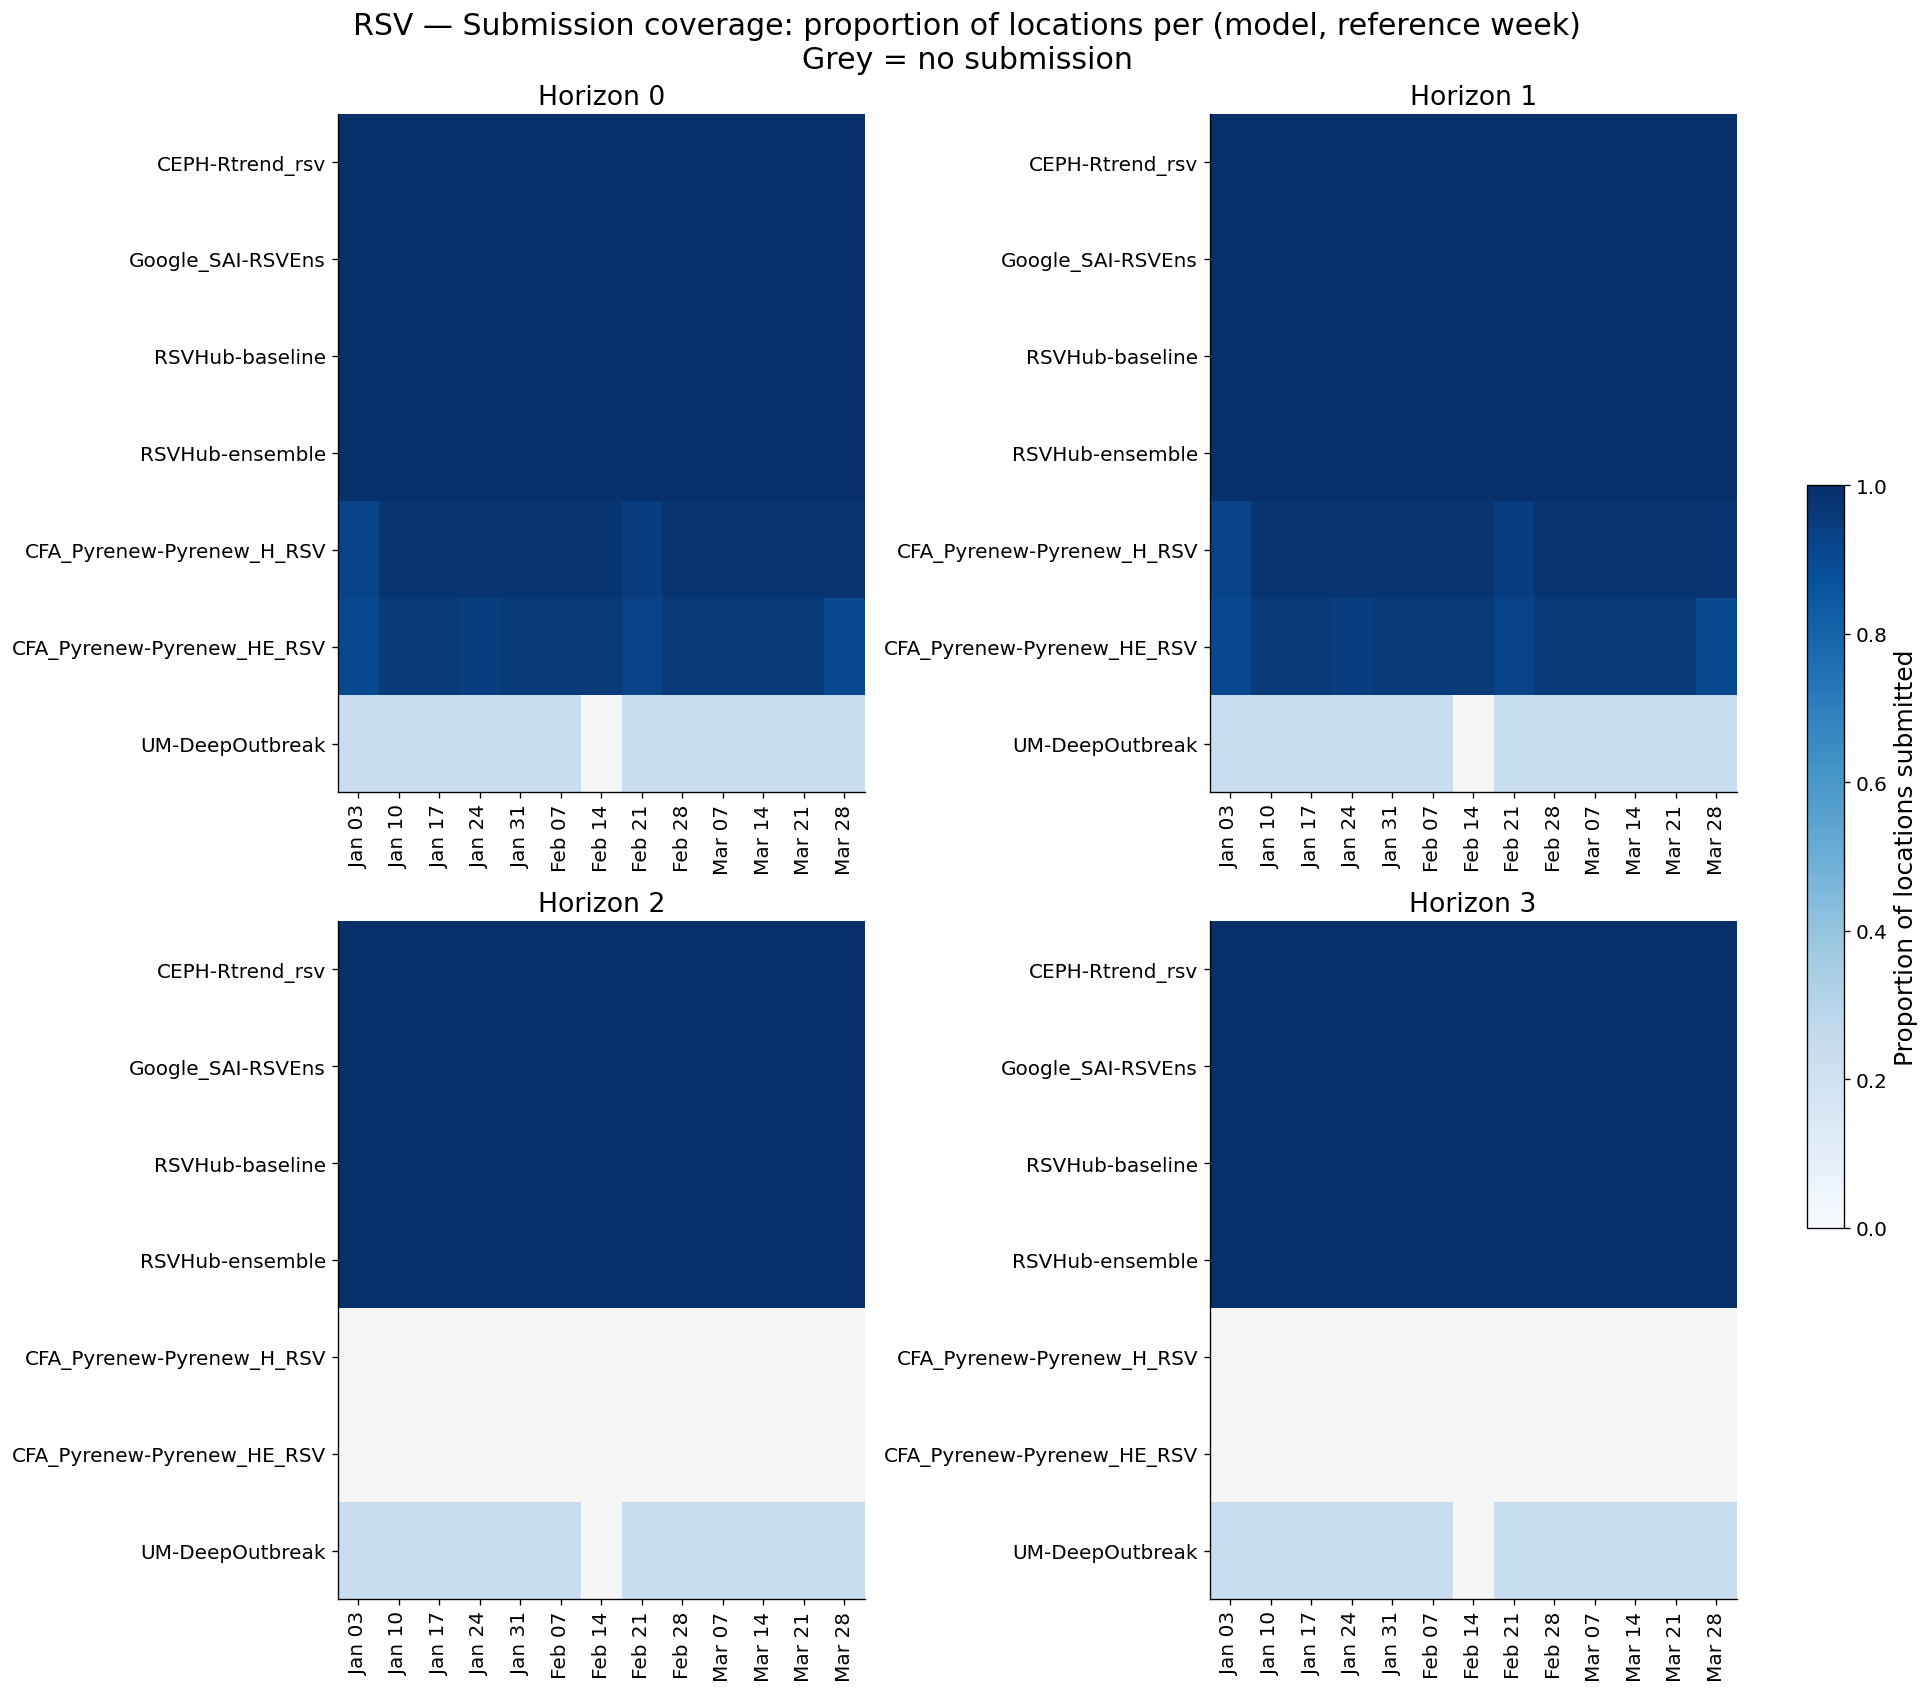

In [26]:
# Heatmap: proportion of locations submitted per (model, week, horizon)
# Built from FORECASTS (not scores) so the heatmap shows what was actually
# submitted, independent of whether truth data is available yet.

forecasts_hm = pd.read_parquet(HUB.forecasts_path)
forecasts_hm = forecasts_hm[
    (forecasts_hm["target"]  == HUB.target_name) &
    (forecasts_hm["horizon"] != -1) &
    (~forecasts_hm["location"].isin(EXCLUDE_LOCS))  # match location scope set above
]

ALL_DATES_HM = sorted(forecasts_hm["reference_date"].dropna().unique())

loc_cov = (
    forecasts_hm.groupby(["model_id", "reference_date", "horizon"])["location"]
    .nunique()
    .div(N_LOCS)
    .reset_index(name="prop_locs")
)

model_order = cov.sort_values("n_tasks", ascending=False)["model_id"].tolist()

P.plot_coverage_heatmap(loc_cov, model_order, ALL_DATES_HM, ALL_HORIZONS, N_LOCS, HUB.label)

## Season Average Comparison

Model,Tasks,Mean WIS,Median WIS,Mean log WIS,Median log WIS,50% coverage,95% coverage,Rel. WIS,Rel. log WIS
Google_SAI-RSVEns,2184,19.95,9.64,0.1960,0.1286,36.4%,82.4%,0.82,0.82
RSVHub-ensemble,2184,23.08,10.53,0.2280,0.1504,38.8%,86.1%,1.00,1.00
RSVHub-baseline,2184,20.00,11.58,0.2571,0.1774,31.1%,91.8%,0.83,1.17
CEPH-Rtrend_rsv,2184,28.06,11.69,0.2651,0.1674,35.2%,76.4%,1.30,1.22


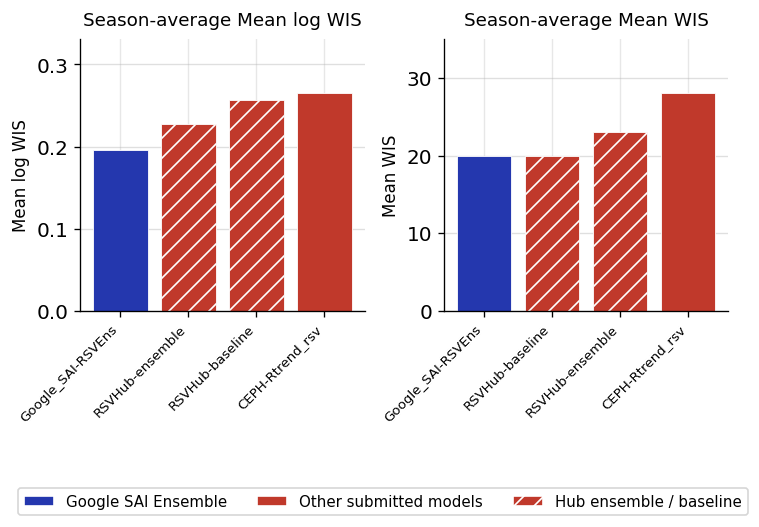

In [27]:
elig = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS)]

summary = (
    elig.groupby("model_id", as_index=False)
    .agg(
        n_tasks        = ("wis",     "size"),
        mean_wis       = ("wis",     "mean"),
        median_wis     = ("wis",     "median"),
        mean_log_wis   = ("log_wis", "mean"),
        median_log_wis = ("log_wis", "median"),
        cov_50         = ("cov_50",  "mean"),
        cov_95         = ("cov_95",  "mean"),
    )
    .sort_values("mean_log_wis")
)

_rel     = pairwise_relative_wis(elig, baseline_model=ENSEMBLE)
_rel_log = pairwise_relative_wis(elig, baseline_model=ENSEMBLE, score_col="log_wis").rename(columns={"rel_wis": "rel_log_wis"})
summary  = summary.merge(_rel, on="model_id", how="left").merge(_rel_log, on="model_id", how="left")

# Diverging colormap for relative WIS: green (< 1) → white (= 1, ensemble) → orange → red (> 1)
_cmap_rel = LinearSegmentedColormap.from_list(
    "rel_wis",
    [(0.00, "#227c49"), (0.25, "#13cb63"), (0.50, "white"), (0.75, "#fcd059"), (1.00, "#d73027")]
)

_summary_display = summary.rename(columns={
    "model_id":        "Model",
    "n_tasks":         "Tasks",
    "mean_wis":        "Mean WIS",
    "median_wis":      "Median WIS",
    "mean_log_wis":    "Mean log WIS",
    "median_log_wis":  "Median log WIS",
    "rel_wis":         "Rel. WIS",
    "rel_log_wis":     "Rel. log WIS",
    "cov_50":          "50% coverage",
    "cov_95":          "95% coverage",
})

_summary_display.to_csv("data/season_summaries/rsv_summary.csv", index=False)

# fix colour scales for relative WIS : log scales w limits:
_rel_wis_log = np.log(_summary_display["Rel. WIS"])
_rel_log_wis_log = np.log(_summary_display["Rel. log WIS"])
_rel_lim = np.nanquantile(np.abs(_rel_wis_log), 0.90)
_rel_log_lim = np.nanquantile(np.abs(_rel_log_wis_log), 0.90)

display(
    _summary_display.style
    .format({
        "Mean WIS":        "{:.2f}",
        "Median WIS":      "{:.2f}",
        "Mean log WIS":    "{:.4f}",
        "Median log WIS":  "{:.4f}",
        "Rel. WIS":        "{:.2f}",
        "Rel. log WIS":    "{:.2f}",
        "50% coverage":    "{:.1%}",
        "95% coverage":    "{:.1%}",
    })
    .background_gradient(subset=["Mean WIS"],     cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Mean log WIS"], cmap="RdYlGn_r", axis=0)
    .background_gradient(
        subset=["Rel. WIS"],
        cmap=_cmap_rel,
        gmap=_rel_wis_log.to_frame(),
        vmin=-_rel_lim,
        vmax=_rel_lim,
        axis=None,
    )
    .background_gradient(
        subset=["Rel. log WIS"],
        cmap=_cmap_rel,
        gmap=_rel_log_wis_log.to_frame(),
        vmin=-_rel_log_lim,
        vmax=_rel_log_lim,
        axis=None,
    )
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index")
)

P.plot_season_bars(summary, MODEL_COLOUR, MODEL_HATCH,include_n_tasks=False, save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_main_summary_bars.png"))

## WIS vs logWIS

In [28]:
all_summary = (
    scores.groupby("model_id", as_index=False)
    .agg(
        mean_wis     = ("wis",     "mean"),
        mean_log_wis = ("log_wis", "mean"),
        n_tasks      = ("wis",     "size"),
    )
)
all_summary["is_eligible"] = all_summary["model_id"].isin(eligible_models)

# P.plot_wis_vs_logwis(all_summary, MODEL_COLOUR, ELIGIBILITY_THRESHOLD)

# Rank comparison (eligible models only)
rank_tbl = (
    all_summary[all_summary["is_eligible"]]
    [["model_id", "mean_wis", "mean_log_wis"]]
    .copy()
)
rank_tbl["wis_rank"]     = rank_tbl["mean_wis"].rank(method="min").astype(int)
rank_tbl["log_wis_rank"] = rank_tbl["mean_log_wis"].rank(method="min").astype(int)
rank_tbl["rank_diff"]    = rank_tbl["log_wis_rank"] - rank_tbl["wis_rank"]
rank_tbl = rank_tbl.sort_values("log_wis_rank")

display(
    rank_tbl[["model_id","mean_wis","wis_rank","mean_log_wis","log_wis_rank","rank_diff"]]
    .rename(columns={
        "model_id":       "Model",
        "mean_wis":       "Mean WIS",
        "wis_rank":       "WIS rank",
        "mean_log_wis":   "Mean log WIS",
        "log_wis_rank":   "log WIS rank",
        "rank_diff":      "Rank diff (log − WIS)",
    })
    .style
    .format({"Mean WIS": "{:.2f}", "Mean log WIS": "{:.4f}"})
    .background_gradient(
        subset=["Rank diff (log − WIS)"], cmap="RdBu_r",
        vmin=-rank_tbl["rank_diff"].abs().max(),
        vmax= rank_tbl["rank_diff"].abs().max(),
    )
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index")
)

Model,Mean WIS,WIS rank,Mean log WIS,log WIS rank,Rank diff (log − WIS)
Google_SAI-RSVEns,19.95,1,0.1960,1,0
RSVHub-ensemble,23.08,3,0.2280,2,-1
RSVHub-baseline,20.00,2,0.2571,3,1
CEPH-Rtrend_rsv,28.06,4,0.2651,4,0


## Performance by Horizon

The per-horizon analysis includes the two CFA models which did not meet our eligibility criteria for the other analyes. These models only submit predictions for two horizons, and therefore do not cover $\geq 80\%$ of the task space. However, they have access to more and better data, and demonstrate good performance on the close horizons for which they submit predictions.

Models sorted by mean WIS across all horizons, ascending. 

In [29]:
# Add the two CFA models to per-horizon analysis
horizon_models = [
    "CFA_Pyrenew-Pyrenew_H_RSV",
    "CFA_Pyrenew-Pyrenew_HE_RSV"
]

Mean WIS by model and horizon:


horizon,0,1,2,3
CFA_Pyrenew-Pyrenew_HE_RSV,14.82,19.74,nan,nan
RSVHub-baseline,16.38,18.17,21.65,25.21
Google_SAI-RSVEns,14.55,17.82,22.29,27.15
CFA_Pyrenew-Pyrenew_H_RSV,17.12,25.27,nan,nan
RSVHub-ensemble,14.30,18.82,27.53,35.06
CEPH-Rtrend_rsv,15.97,23.48,33.37,43.86



Mean log WIS by model and horizon:


horizon,0,1,2,3
CFA_Pyrenew-Pyrenew_HE_RSV,0.1417,0.1825,nan,nan
Google_SAI-RSVEns,0.1609,0.1813,0.2114,0.2438
CFA_Pyrenew-Pyrenew_H_RSV,0.1729,0.2315,nan,nan
RSVHub-ensemble,0.1538,0.1893,0.2652,0.3329
RSVHub-baseline,0.2056,0.2332,0.2791,0.3303
CEPH-Rtrend_rsv,0.1751,0.2288,0.3009,0.3898


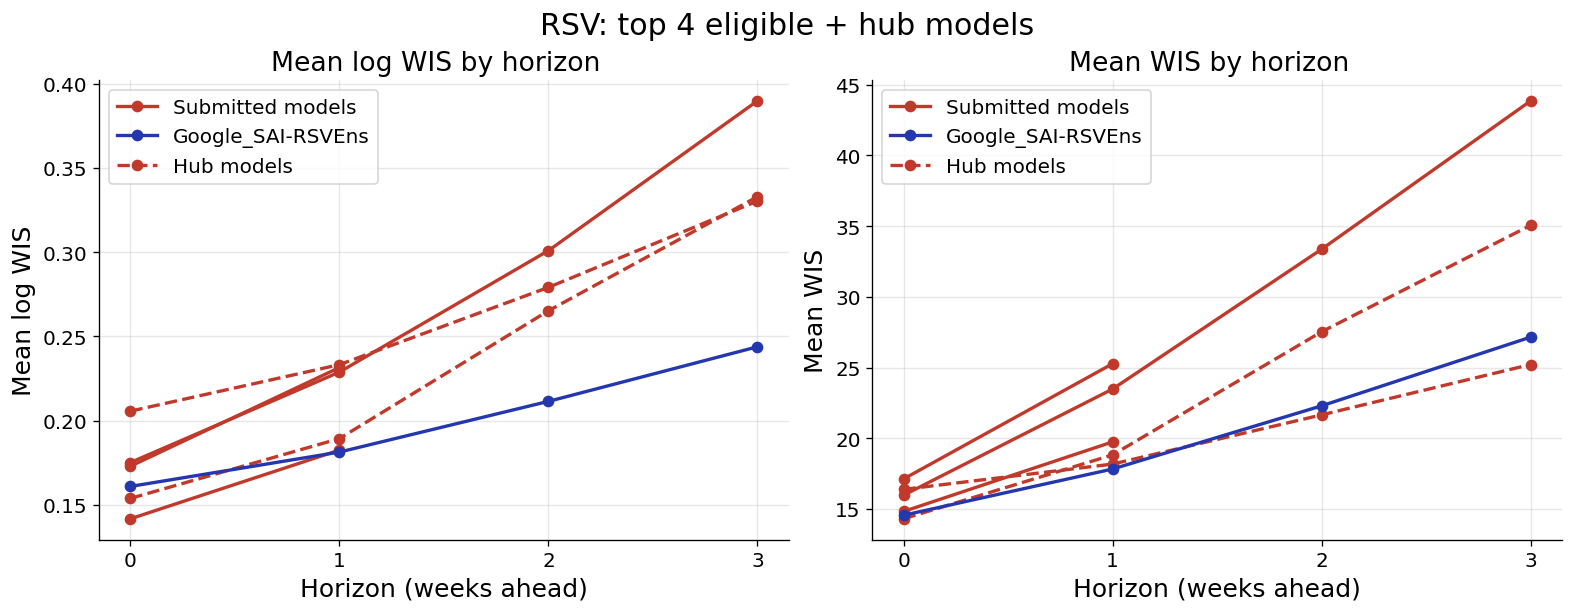

In [30]:
# Mean WIS & log WIS by model × horizon (eligible + hub models + horizon-only models)
elig_hor = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS | set(horizon_models))]

by_hor_wis = (
    elig_hor.groupby(["model_id", "horizon"])["wis"]
    .mean()
    .unstack("horizon")
    .round(2)
)
by_hor_log = (
    elig_hor.groupby(["model_id", "horizon"])["log_wis"]
    .mean()
    .unstack("horizon")
    .round(4)
)

by_hor_wis = by_hor_wis.loc[by_hor_wis.mean(axis=1).sort_values().index]
by_hor_log = by_hor_log.loc[by_hor_log.mean(axis=1).sort_values().index]

print("Mean WIS by model and horizon:")
tmp = by_hor_wis.copy()
tmp.columns = tmp.columns.astype(int)   # make horizon labels integers
tmp.index.name = None
display(
    tmp.style
    .apply(C.median_gradient, axis=0)
    .format("{:.2f}")
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    )
)

print("\nMean log WIS by model and horizon:")
tmp = by_hor_log.copy()
tmp.columns = tmp.columns.astype(int)
tmp.index.name = None
display(
    tmp.style
    .apply(C.median_gradient, axis=0)
    .format("{:.4f}")
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    )
)

P.plot_by_horizon(by_hor_wis, by_hor_log, ALL_HORIZONS, MODEL_COLOUR,
                  hub_models=HUB_MODELS, hub_label=HUB.label, main_model=GOOGLE,
                  save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_by_horizon.png"))

## Performance by State

In [31]:
# Mean WIS & log WIS per jurisdiction (eligible + hub models)
_loc_scores = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS)]

by_loc_wis = (
    _loc_scores.groupby(["model_id", "location"])["wis"]
    .mean().unstack("location").round(2)
)
by_loc_log = (
    _loc_scores.groupby(["model_id", "location"])["log_wis"]
    .mean().unstack("location").round(4)
)

# Location names from flu
from hub_config import FLU_HUB as _FLU_HUB
_raw = pd.read_parquet(_FLU_HUB.truth_path)
_loc_names = (
    _raw[["location", "location_name"]].dropna()
    .drop_duplicates("location").set_index("location")["location_name"].to_dict()
)
del _raw, _FLU_HUB

by_loc_wis.columns = [_loc_names.get(c, c) for c in by_loc_wis.columns]
by_loc_log.columns = [_loc_names.get(c, c) for c in by_loc_log.columns]

# Sort models by overall mean log WIS (best first)
by_loc_log = by_loc_log.loc[by_loc_log.mean(axis=1).sort_values().index]
by_loc_wis = by_loc_wis.reindex(by_loc_log.index)

# Table: Google + main ensemble + top-3 eligible models (by season-average log WIS)
_top3 = [
    m for m in by_loc_log.mean(axis=1).sort_values().index
    if m in eligible_models and m not in {GOOGLE, ENSEMBLE}
][:3]
_key = [m for m in ([GOOGLE, ENSEMBLE] + _top3) if m in by_loc_log.index]
_tbl = by_loc_log.loc[_key].T
if GOOGLE in _tbl.columns:
    _tbl = _tbl.sort_values(GOOGLE, ascending=True)

print("Mean log WIS per jurisdiction (sorted best → worst for Google):")
display(
    _tbl.style
    .background_gradient(cmap="RdYlGn_r", axis=0)
    .format("{:.4f}")
    .apply_index(
        lambda idx: [
            f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else ""
            for v in idx
        ],
        axis=1,
    )
)

Mean log WIS per jurisdiction (sorted best → worst for Google):


model_id,Google_SAI-RSVEns,RSVHub-ensemble,RSVHub-baseline,CEPH-Rtrend_rsv
North Carolina,0.0725,0.1249,0.0830,0.1766
Florida,0.0976,0.1623,0.1012,0.2750
Virginia,0.0980,0.1219,0.1545,0.1440
Mississippi,0.1071,0.1313,0.1349,0.1423
Maryland,0.1079,0.1377,0.1417,0.1618
Tennessee,0.1085,0.1747,0.1263,0.2330
Illinois,0.1169,0.1436,0.1308,0.1674
New Jersey,0.1178,0.1273,0.0953,0.1372
California,0.1201,0.1318,0.1442,0.1315
Texas,0.1271,0.1893,0.1259,0.2835


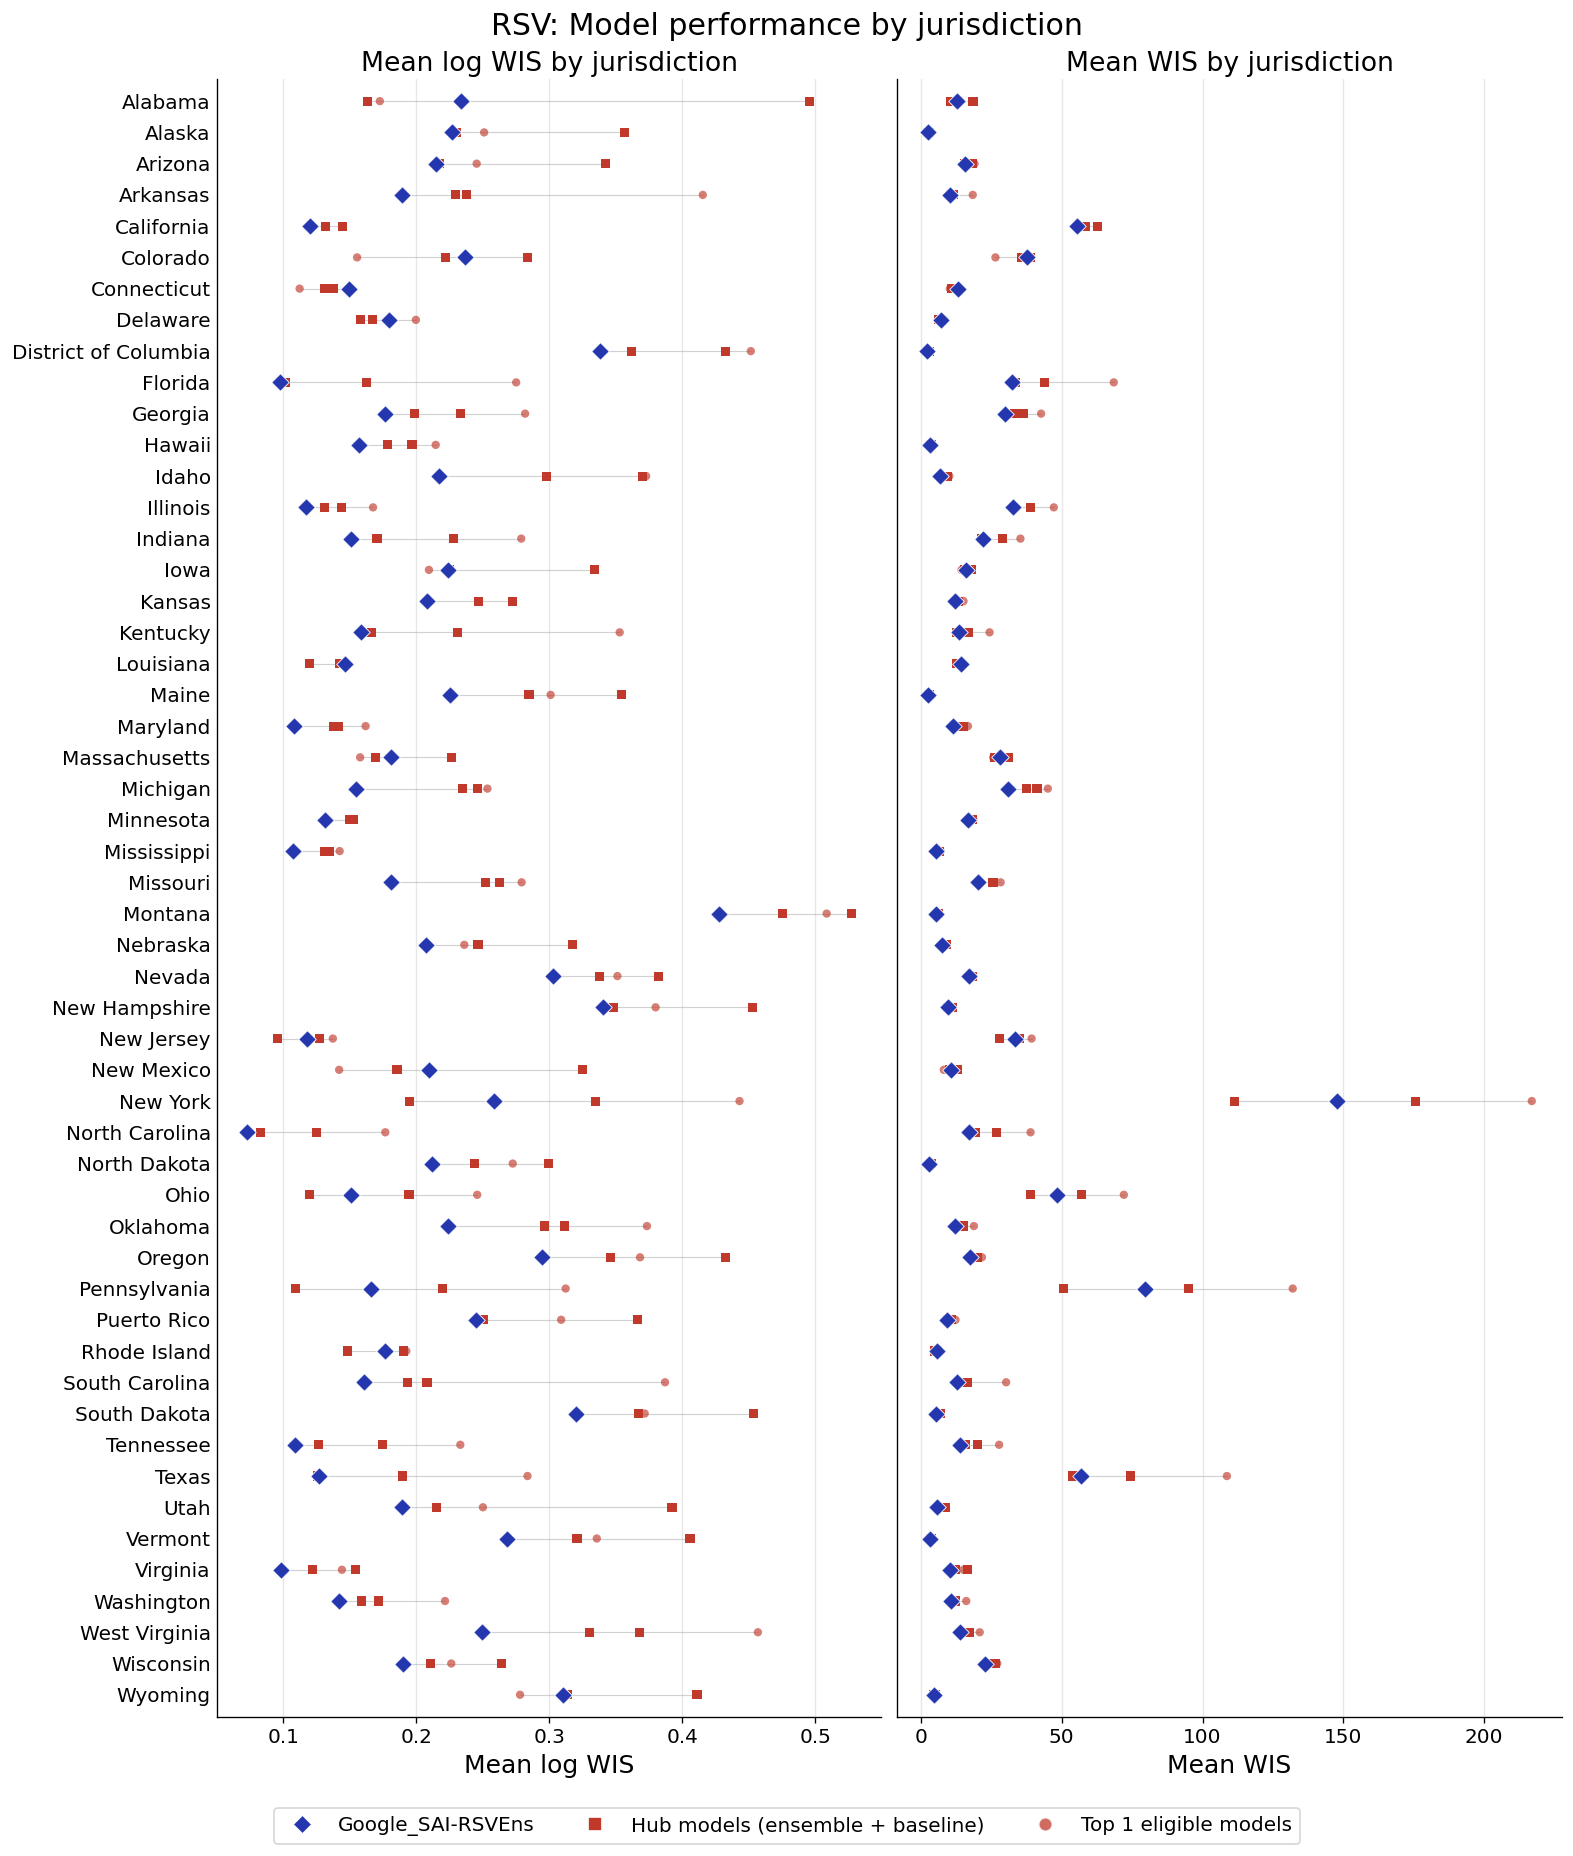

In [32]:
P.plot_by_location(
    by_loc_wis, by_loc_log, MODEL_COLOUR,
    hub_models=HUB_MODELS,
    hub_label=HUB.label,
    main_model=GOOGLE,
    save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_by_location.png"),
)

## Performance over Reference Time

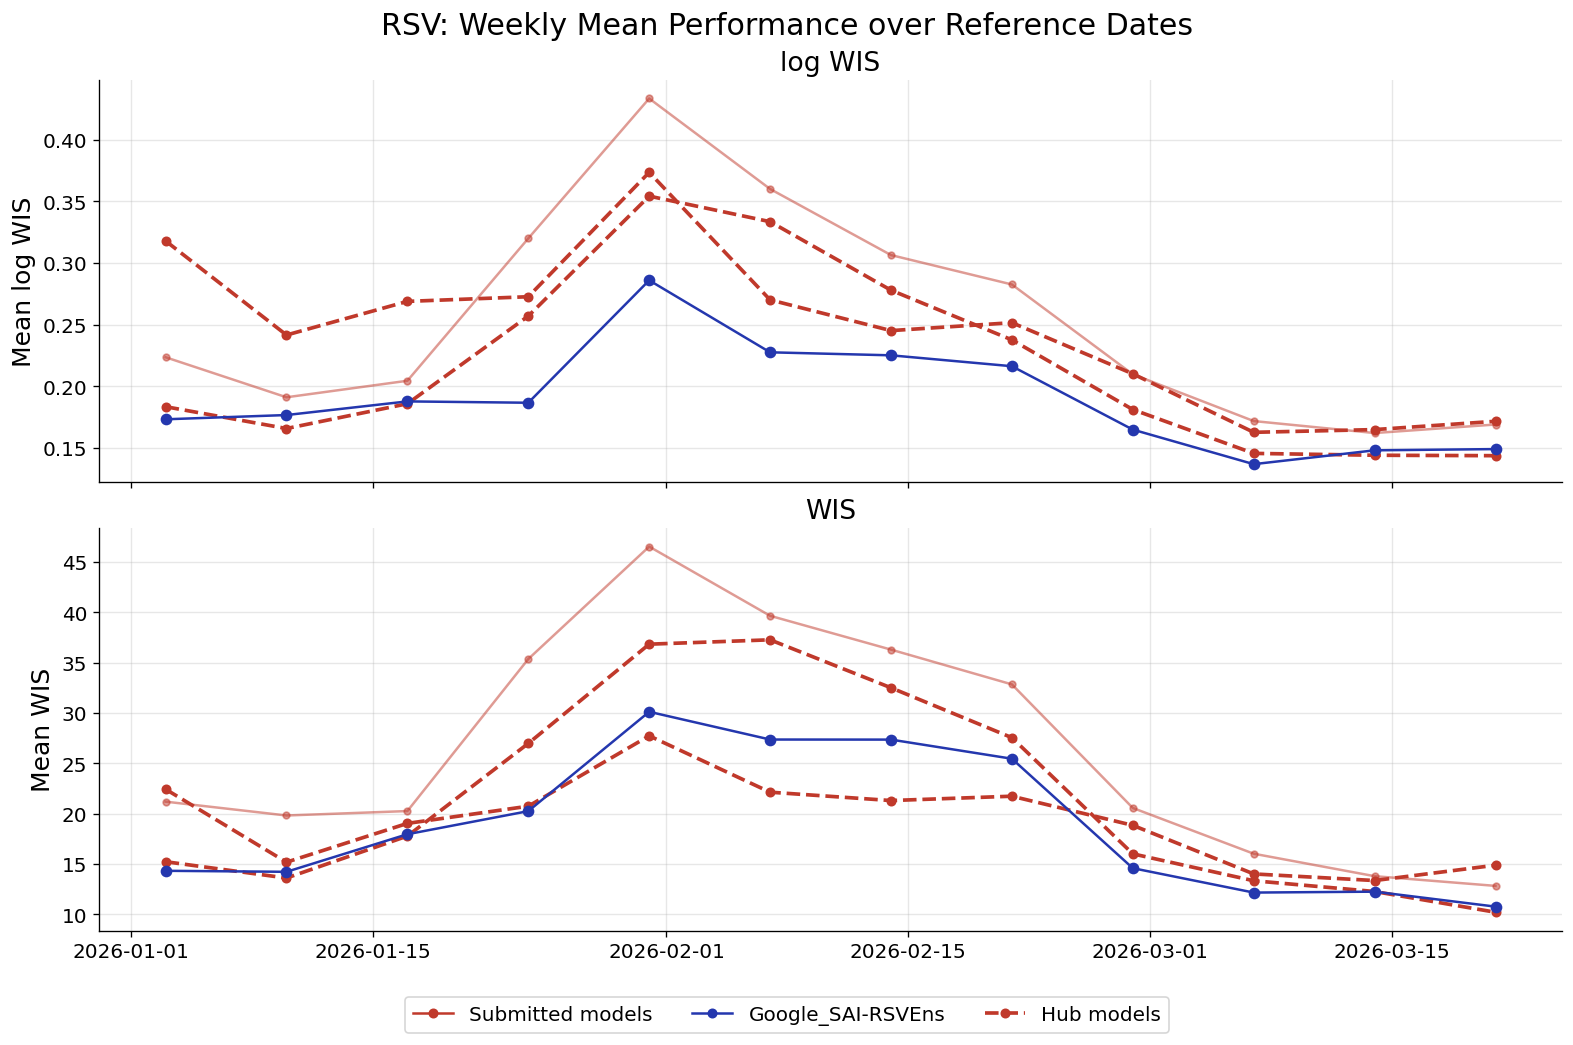

Reference date,Best WIS model,Best WIS,Best log WIS model,Best log WIS
2026-01-03,Google_SAI-RSVEns,14.31,Google_SAI-RSVEns,0.1733
2026-01-10,RSVHub-ensemble,13.60,RSVHub-ensemble,0.1658
2026-01-17,RSVHub-ensemble,17.77,RSVHub-ensemble,0.1859
2026-01-24,Google_SAI-RSVEns,20.24,Google_SAI-RSVEns,0.1867
2026-01-31,RSVHub-baseline,27.73,Google_SAI-RSVEns,0.2860
2026-02-07,RSVHub-baseline,22.13,Google_SAI-RSVEns,0.2276
2026-02-14,RSVHub-baseline,21.30,Google_SAI-RSVEns,0.2252
2026-02-21,RSVHub-baseline,21.73,Google_SAI-RSVEns,0.2163
2026-02-28,Google_SAI-RSVEns,14.57,Google_SAI-RSVEns,0.1649
2026-03-07,Google_SAI-RSVEns,12.15,Google_SAI-RSVEns,0.1369


In [33]:
plot_models = sorted(set(eligible_models) | HUB_MODELS)

# Weekly mean WIS / log WIS averaged over horizons and locations
weekly = (
    scores[scores["model_id"].isin(plot_models)]
    .groupby(["model_id", "reference_date"])[["wis", "log_wis"]]
    .mean()
    .reset_index()
)

P.plot_weekly_scores(weekly, plot_models, MODEL_COLOUR, HUB_MODELS, HUB.label, main_model=GOOGLE,
                     save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_weekly_performance.png"))

# Best model by week (eligible only)
weekly_elig = weekly[weekly["model_id"].isin(eligible_models)]

best_wis_idx = weekly_elig.groupby("reference_date")["wis"].idxmin()
best_log_idx = weekly_elig.groupby("reference_date")["log_wis"].idxmin()

best_by_week = pd.DataFrame({
    "Reference date":    weekly_elig.loc[best_wis_idx, "reference_date"].dt.strftime("%Y-%m-%d").values,
    "Best WIS model":    weekly_elig.loc[best_wis_idx, "model_id"].values,
    "Best WIS":          weekly_elig.loc[best_wis_idx, "wis"].values,
    "Best log WIS model":weekly_elig.loc[best_log_idx, "model_id"].values,
    "Best log WIS":      weekly_elig.loc[best_log_idx, "log_wis"].values,
})

display(
    best_by_week.style
    .format({"Best WIS": "{:.2f}", "Best log WIS": "{:.4f}"})
    .hide(axis="index")
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Best WIS model", "Best log WIS model"], axis=0,
    )
)

## Standardised Rank Distribution

* Model doesn't show (much) Q1 area: best performance still did not achieve very high ranks. 
* Model doesn't show (much) Q4 area: worst performance still did not achieve very low ranks. 

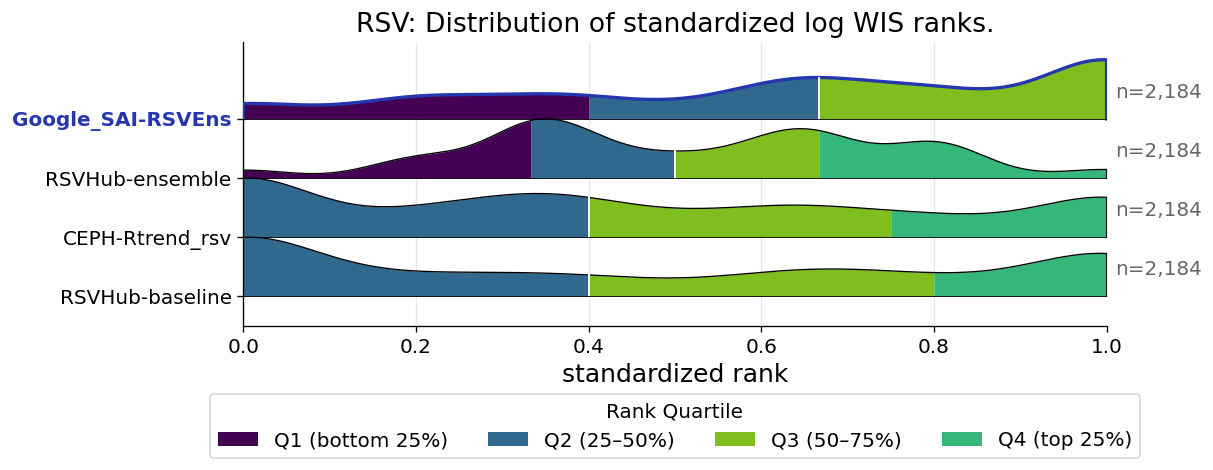

In [34]:
P.plot_rank_distribution(
    scores,
    eligible_models,
    MODEL_COLOUR,
    score_col="log_wis",
    top_n=10,
    main_model=GOOGLE,
    hub_label=HUB.label,
    show_n_tasks=True,
    save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_rank_distribution.png")
)